In [2]:
import pandas as pd

In [3]:
phf19_data = pd.read_csv('/users/s/h/shuhang/PHF19/phf19_data_30mar2026.csv')

In [4]:
phf19_data.sort_values('ic50', ascending=True).head(5)

,name,smiles,ic50,active
207,UNC10415782,Cn1nc(Br)c2c(N3CCC[C@@H](NC4CCC4)C3)nc(N3CCC(F...,0.090,1
210,UNC10415785,Cn1nc(Br)c2c(N3CCC[C@H](NC4CC4)CC3)nc(N3CCC(F)...,0.101,1
201,UNC10415762,Cn1nc(Br)c2c(N3CCCC(NC4CCC4)C3)nc(N3CCC(F)(F)C...,0.110,1
203,UNC10415778,Cn1nc(Br)c2c(N3CCC[C@H](NC4CCC4)CC3)nc(N3CCC(F...,0.140,1
182,UNC10415739,Cn1nc(Br)c2c(N3CCCC(NC4CC4)CC3)nc(N3CCC(F)(F)C...,0.140,1


In [5]:
from pathlib import Path
from rdkit import Chem

DRACO = Path(".").resolve()

# Two docking campaigns: same compound library, different receptor frames / prep
RUN_SDFS = {
    "6WAU-SAR-30mar2026": DRACO / "6WAU-SAR-30mar2026" / "top01_frame0007_pocket000_ligands_ranked.sdf",
    "6WAU-static": DRACO / "6WAU-SAR-30mar2026" / "top02_frame0000_pocket000_ligands_ranked.sdf",
    #"6WAU-lig-refined-3apr2026": DRACO / "6WAU-lig-refined-3apr2026" / "top01_frame0000_pocket000_ligands_ranked.sdf",
}

RUN_LABELS = {
    "6WAU-SAR-30mar2026": "SAR (frame 7)",
    #"6WAU-lig-refined-3apr2026": "Lig-refined (frame 0)",
    "6WAU-static": "SAR (frame 0)",
}

RUN_COLORS = {
    "6WAU-SAR-30mar2026": "steelblue",
    #"6WAU-lig-refined-3apr2026": "darkorange",
    "6WAU-static": "darkorange",
}


def load_mols(sdf_path: Path):
    supp = Chem.SDMolSupplier(str(sdf_path))
    return [mol for mol in supp if mol is not None]


docking_mols = {run: load_mols(path) for run, path in RUN_SDFS.items()}

# Keep `mols` as the SAR run for any ad-hoc cells that still expect a single list
mols = docking_mols["6WAU-SAR-30mar2026"]

[22:55:03] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[22:55:03] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[22:55:03] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[22:55:03] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[22:55:03] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[22:55:03] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[22:55:03] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[22:55:03] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[22:55:03] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol

In [6]:
from rdkit.Chem import ChemicalFeatures
from rdkit import RDConfig
import numpy as np
import pandas as pd

# Simple PDB parser to extract atom coordinates for oxygen atoms
def get_oxygen_atoms_from_pdb(pdb_path):
    oxy_coords = []
    oxy_names = []
    oxy_resids = []
    oxy_resnames = []
    with open(pdb_path, "rt") as f:
        for line in f:
            if line.startswith("ATOM") or line.startswith("HETATM"):
                atom_name = line[12:16].strip()
                if atom_name.startswith("O"):
                    x = float(line[30:38])
                    y = float(line[38:46])
                    z = float(line[46:54])
                    resid = int(line[22:26])
                    resname = line[17:20].strip()
                    oxy_coords.append([x, y, z])
                    oxy_names.append(atom_name)
                    oxy_resids.append(resid)
                    oxy_resnames.append(resname)
    return (
        np.array(oxy_coords), 
        oxy_names, 
        oxy_resids,
        oxy_resnames
    )

# Load receptor structure: extract oxygen atoms and their coordinates from PDB
frame_pdb_path = DRACO / "6WAU-SAR-30mar2026" / "frames" / "frame_0007.pdb"
receptor_oxy_coords, receptor_oxy_names, receptor_oxy_resids, receptor_oxy_resnames = get_oxygen_atoms_from_pdb(str(frame_pdb_path))

results = []

for mol in mols:
    bromine_atoms = [atom.GetIdx() for atom in mol.GetAtoms() if atom.GetSymbol() == "Br"]
    if not bromine_atoms:
        continue
    conf = mol.GetConformer() if mol.GetNumConformers() > 0 else None
    if conf is None:
        continue

    for br_idx in bromine_atoms:
        br_pos = np.array(conf.GetAtomPosition(br_idx))
        dists = np.linalg.norm(receptor_oxy_coords - br_pos, axis=1)
        min_dist_idx = np.argmin(dists)
        min_dist = dists[min_dist_idx]
        closest_oxy_name = receptor_oxy_names[min_dist_idx]
        closest_oxy_resid = receptor_oxy_resids[min_dist_idx]
        closest_oxy_resname = receptor_oxy_resnames[min_dist_idx]
        results.append({
            'smiles': Chem.MolToSmiles(mol),
            'bromine_atom_index': br_idx,
            'closest_oxygen_atom_index': min_dist_idx,
            'distance': min_dist,
            'oxygen_atom_name': closest_oxy_name,
            'oxygen_resid': closest_oxy_resid,
            'oxygen_resname': closest_oxy_resname,
        })

df_bromine_oxygen_dist = pd.DataFrame(results)
df_bromine_oxygen_dist

,smiles,bromine_atom_index,closest_oxygen_atom_index,distance,oxygen_atom_name,oxygen_resid,oxygen_resname
0,Cn1nc(Br)c2c(N3CCC[C@H](NC4CCC4)C(C)(C)C3)nc(N...,4,11,3.262881,O,8,ARG
1,C[C@@H]1CN(c2nc(N3CCC(F)(F)C3)nc3c2c(Br)nn3C)C...,7,10,3.352369,O,7,CYS
2,C[C@@H]1CN(c2nc(N3CCC(F)(F)C3)nc3c2c(Br)nn3C)C...,7,10,3.707800,O,7,CYS
3,Cn1nc(Br)c2c(N3CCC[C@@H](NC4CC4)C3)nc(N3CCC(F)...,4,10,3.697389,O,7,CYS
4,Cn1nc(Br)c2c(N3CCC[C@@H](NC4CC4)C3)nc(N3CCC(F)...,4,10,3.697389,O,7,CYS
...,...,...,...,...,...,...,...
138,CCOc1nc(N2CCC(NCC3CC3)CC2)c2c(Br)nn(C)c2n1,5,11,3.627148,O,8,ARG
139,COc1cc2nc(Cl)nc(N3CCCN(CC4CC4)CC3)c2cc1Br,11,11,3.201549,O,8,ARG
140,COc1nc(N2CC[C@@H](CCC3CC3)C2)c2c(Br)nn(C)c2n1,5,10,3.384915,O,7,CYS
141,[H]/N=c1\[nH]cc(Br)cc1C(=O)N1CCCN(CC2CC2)CC1,14,61,3.875393,O,40,TRP


In [7]:
mols[0].GetPropsAsDict()

{'SMILES': 'Cn1nc(Br)c2c(N3CCCC(NC4CCC4)C(C)(C)C3)nc(N3CCC(F)(F)C3)nc21',
 'minimizedAffinity': -8.28219,
 'CNNscore': 0.9562903047,
 'CNNaffinity': 8.0142393112,
 'CNN_VS': 7.663939476,
 'CNNaffinity_variance': 0.3482426703}

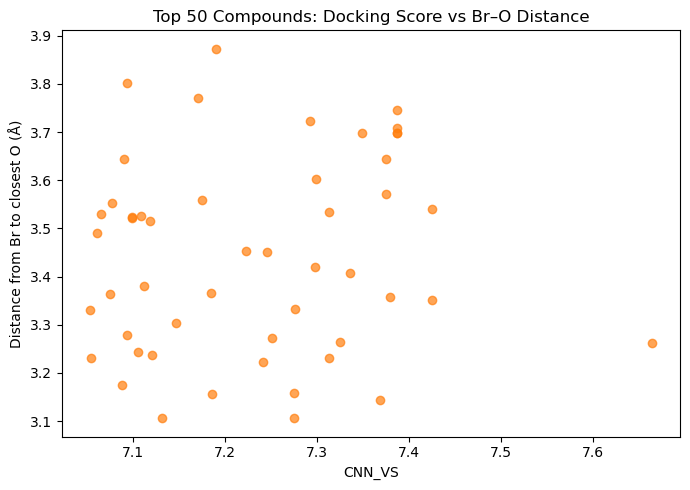

In [8]:
# Assume "mols" is a list of RDKit molecules and that for each mol,
# there is a docking score (e.g., stored in a property, e.g., "cnn_affinity" or "vina_score").
# We'll default to "cnn_affinity" if present, or "vina_score" otherwise.
import matplotlib.pyplot as plt

# Determine the docking score property name
score_prop = None
if mols and mols[0].HasProp("CNN_VS"):
    score_prop = "CNN_VS"
elif mols and mols[0].HasProp("CNNaffinity"):
    score_prop = "CNNaffinity"
elif mols and mols[0].HasProp("CNNscore"):
    score_prop = "CNNscore"
else:
    raise RuntimeError("No recognizable docking score property found in molecules.")

# Prepare DataFrame with docking score and Br-O distance
df_bromine_oxygen_dist = df_bromine_oxygen_dist.copy()
scores = []
for smi in df_bromine_oxygen_dist["smiles"]:
    score = None
    for mol in mols:
        if Chem.MolToSmiles(mol) == smi and mol.HasProp(score_prop):
            score = float(mol.GetProp(score_prop))
            break
    scores.append(score)

df_bromine_oxygen_dist["docking_score"] = scores

# Drop rows where no docking score was matched
df_bromine_oxygen_dist = df_bromine_oxygen_dist.dropna(subset=["docking_score"])

# Sort by docking score (ascending: more negative = better for Vina; descending for CNN if higher is better)
ascending = score_prop == "vina_score"
df_sorted = df_bromine_oxygen_dist.sort_values("docking_score", ascending=ascending)

# Take the first 50 compounds
df_top50 = df_sorted.head(50)

# Plot docking score vs Br–O distance for these compounds
plt.figure(figsize=(7, 5))
plt.scatter(df_top50["docking_score"], df_top50["distance"], c="C1", alpha=0.7)
plt.xlabel(f"CNN_VS")
plt.ylabel("Distance from Br to closest O (Å)")
plt.title(f"Top 50 Compounds: Docking Score vs Br–O Distance")
plt.tight_layout()
plt.show()

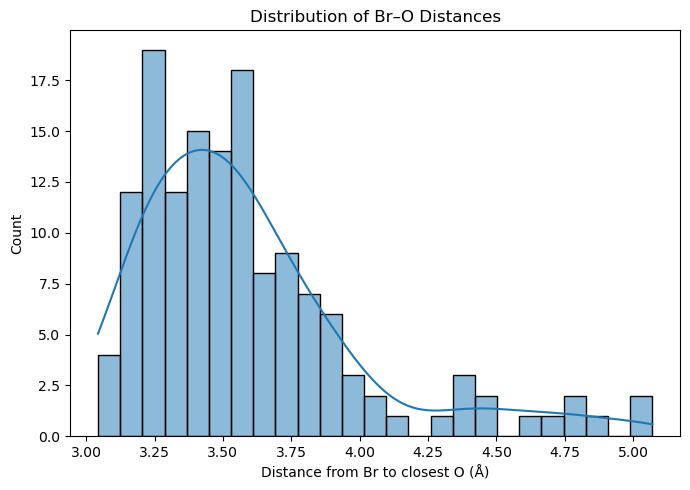

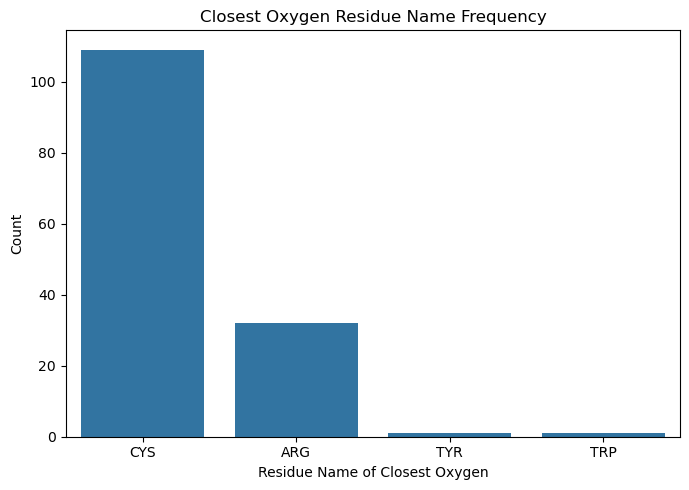

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot distribution (histogram + KDE) of bromine-oxygen distances
plt.figure(figsize=(7, 5))
sns.histplot(df_bromine_oxygen_dist["distance"], kde=True, bins=25)
plt.xlabel("Distance from Br to closest O (Å)")
plt.ylabel("Count")
plt.title("Distribution of Br–O Distances")
plt.tight_layout()
plt.show()

# Plot bar plot of oxygen_resname counts (residue names)
plt.figure(figsize=(7, 5))
sns.countplot(data=df_bromine_oxygen_dist, x="oxygen_resname", order=df_bromine_oxygen_dist["oxygen_resname"].value_counts().index)
plt.xlabel("Residue Name of Closest Oxygen")
plt.ylabel("Count")
plt.title("Closest Oxygen Residue Name Frequency")
plt.tight_layout()
plt.show()

In [10]:
min(df_bromine_oxygen_dist["distance"])

3.043091622018633

In [11]:
{RUN_LABELS[k]: len(v) for k, v in docking_mols.items()}

{'SAR (frame 7)': 262, 'SAR (frame 0)': 262}

In [12]:
len(docking_mols['6WAU-SAR-30mar2026'])

262

In [13]:
for run_name, ms in docking_mols.items():
    print(RUN_LABELS[run_name])
    print(ms[0].GetPropsAsDict() if ms else "(no molecules)")
    print()

SAR (frame 7)
{'SMILES': 'Cn1nc(Br)c2c(N3CCCC(NC4CCC4)C(C)(C)C3)nc(N3CCC(F)(F)C3)nc21', 'minimizedAffinity': -8.28219, 'CNNscore': 0.9562903047, 'CNNaffinity': 8.0142393112, 'CNN_VS': 7.663939476, 'CNNaffinity_variance': 0.3482426703}

SAR (frame 0)
{'SMILES': 'COc1ccc2nc(C(F)(F)F)nc(N3CCCC(N4CCCC4)CC3)c2c1', 'minimizedAffinity': -4.5767, 'CNNscore': 0.8845541477, 'CNNaffinity': 6.9732551575, 'CNN_VS': 6.1682219505, 'CNNaffinity_variance': 0.9358286858}



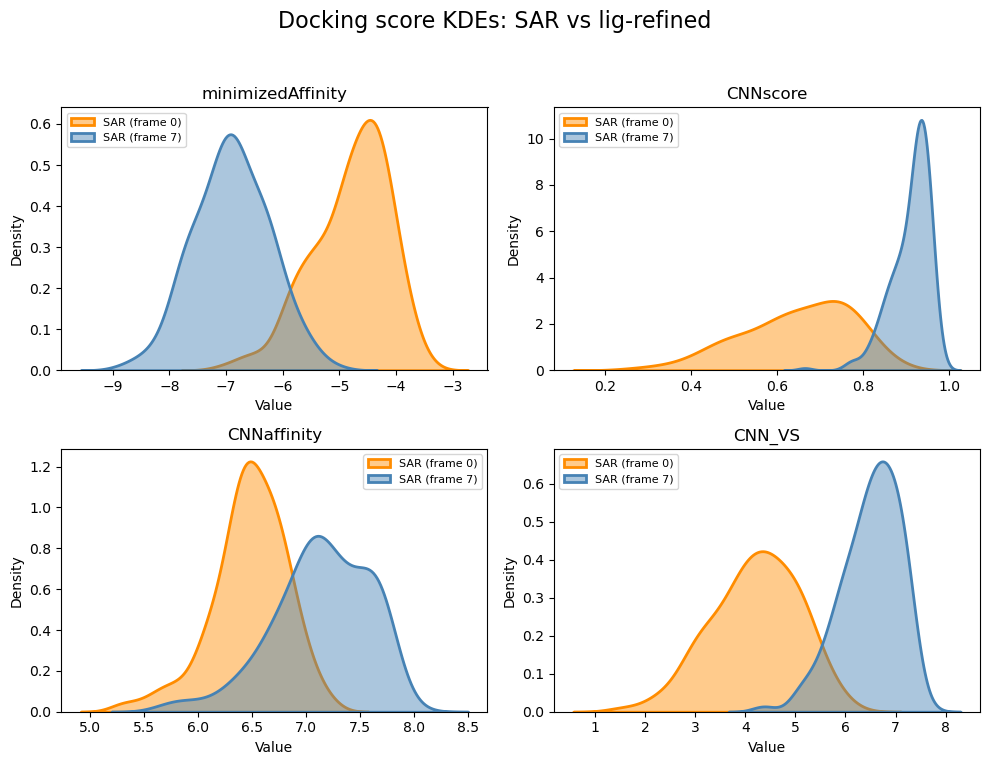

In [14]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

def series_for_mols(ms, key):
    out = []
    for mol in ms:
        props = mol.GetPropsAsDict()
        out.append(float(props.get(key, float("nan"))))
    return out

keys_titles = [
    ("minimizedAffinity", "minimizedAffinity"),
    ("CNNscore", "CNNscore"),
    ("CNNaffinity", "CNNaffinity"),
    ("CNN_VS", "CNN_VS"),
]

# Switch the plotting order (and colors/labels) by reversing the items
run_names = list(docking_mols.keys())[::-1]

fig, axs = plt.subplots(2, 2, figsize=(10, 8))
fig.suptitle("Docking score KDEs: SAR vs lig-refined", fontsize=16)

for ax, (key, title) in zip(axs.flat, keys_titles):
    for run_name in run_names:
        ms = docking_mols[run_name]
        vals = np.array(series_for_mols(ms, key))
        vals = vals[np.isfinite(vals)]
        if len(vals) > 1:
            sns.kdeplot(
                vals,
                ax=ax,
                fill=True,
                color=RUN_COLORS[run_name],
                alpha=0.45,
                label=RUN_LABELS[run_name],
                linewidth=2,
                bw_adjust=1.1
            )
        else:
            # Too few points for KDE, just show points
            ax.scatter(vals, np.zeros_like(vals), color=RUN_COLORS[run_name], label=RUN_LABELS[run_name])
    ax.set_title(title)
    ax.set_xlabel("Value")
    ax.set_ylabel("Density")
    ax.legend(fontsize=8)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

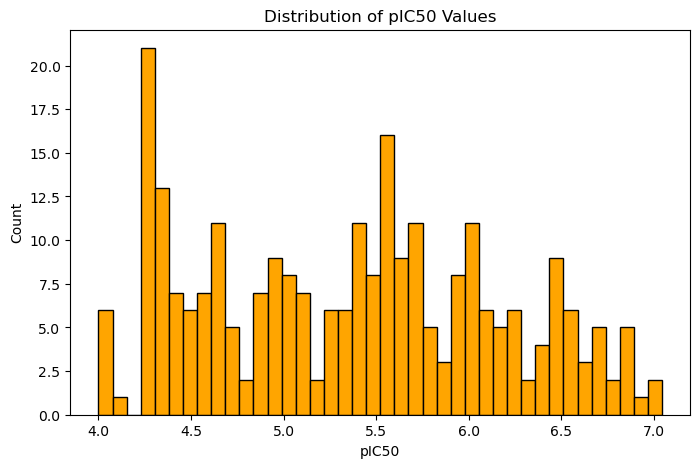

In [15]:
import matplotlib.pyplot as plt
import numpy as np

# Convert IC50 values (uM) to pIC50s, ignoring 0s and nans
ic50s_um = phf19_data['ic50'].replace(0, np.nan).dropna()
pIC50s = 6 - np.log10(ic50s_um)

plt.figure(figsize=(8, 5))
plt.hist(pIC50s, bins=40, color='orange', edgecolor='black')
plt.xlabel('pIC50')
plt.ylabel('Count')
plt.title('Distribution of pIC50 Values')
plt.show()

In [16]:
# Merge sdf properties to phf19_data using compound name (both docking runs)

import numpy as np

molprops = []
for run_name, ms in docking_mols.items():
    for mol in ms:
        props = mol.GetPropsAsDict()
        props["_Name"] = mol.GetProp("_Name") if mol.HasProp("_Name") else None
        props["run"] = run_name
        molprops.append(props)

mol_df = pd.DataFrame(molprops)

combined_df = pd.merge(
    phf19_data,
    mol_df,
    how="inner",
    left_on="name",
    right_on="_Name",
)

ic50_um = combined_df["ic50"].replace(0, np.nan)
combined_df["pIC50"] = 6 - np.log10(ic50_um)

SAR (frame 7)  CNN_VS vs pIC50: R²=0.381  Spearman r=0.638  Pearson r=0.617
SAR (frame 0)  CNN_VS vs pIC50: R²=0.093  Spearman r=-0.293  Pearson r=-0.305
SAR (frame 7)  CNNaffinity vs pIC50: R²=0.308  Spearman r=0.556  Pearson r=0.555
SAR (frame 0)  CNNaffinity vs pIC50: R²=0.060  Spearman r=0.201  Pearson r=0.244


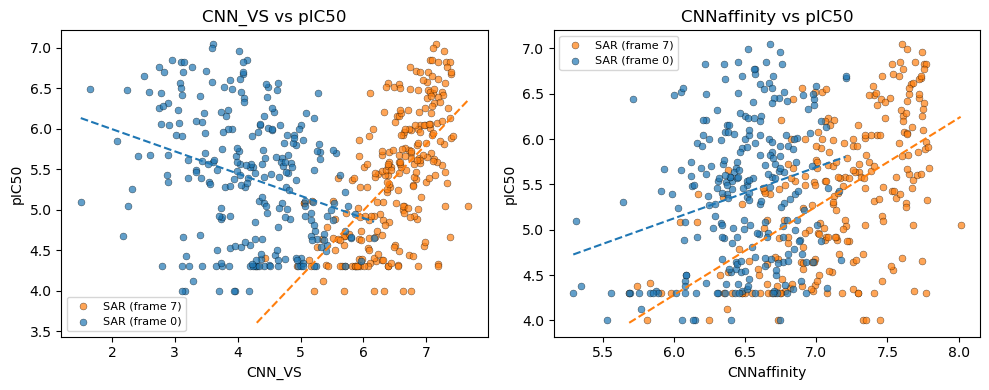

In [17]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import linregress, spearmanr, pearsonr

# Use blue and orange for comparison
SCATTER_COLORS = {
    "6WAU-SAR-30mar2026": "#ff7f0e",         # matplotlib orange
    #"6WAU-lig-refined-3apr2026": "#ff7f0e",  # matplotlib orange
    "6WAU-static": "#1f77b4",  # matplotlib blue
}

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
for run_name, sub in combined_df.groupby("run"):
    x1 = sub["CNN_VS"].values
    y1 = sub["pIC50"].values
    c = SCATTER_COLORS[run_name]
    plt.scatter(x1, y1, color=c, alpha=0.7, label=RUN_LABELS[run_name], s=25, edgecolor='k', linewidth=0.3)
    mask1 = ~np.isnan(x1) & ~np.isnan(y1)
    if mask1.sum() > 2:
        slope1, intercept1, r_value1, _, _ = linregress(x1[mask1], y1[mask1])
        xs = np.linspace(x1[mask1].min(), x1[mask1].max(), 50)
        plt.plot(xs, intercept1 + slope1 * xs, color=c, linestyle="--", linewidth=1.5)
        spearman_r1, _ = spearmanr(x1[mask1], y1[mask1])
        pearson_r1, _ = pearsonr(x1[mask1], y1[mask1])
        print(
            f"{RUN_LABELS[run_name]}  CNN_VS vs pIC50: R²={r_value1**2:.3f}  Spearman r={spearman_r1:.3f}  Pearson r={pearson_r1:.3f}"
        )

plt.xlabel("CNN_VS")
plt.ylabel("pIC50")
plt.title("CNN_VS vs pIC50")
plt.legend(fontsize=8)

plt.subplot(1, 2, 2)
for run_name, sub in combined_df.groupby("run"):
    x2 = sub["CNNaffinity"].values
    y2 = sub["pIC50"].values
    c = SCATTER_COLORS[run_name]
    plt.scatter(x2, y2, color=c, alpha=0.7, label=RUN_LABELS[run_name], s=25, edgecolor='k', linewidth=0.3)
    mask2 = ~np.isnan(x2) & ~np.isnan(y2)
    if mask2.sum() > 2:
        slope2, intercept2, r_value2, _, _ = linregress(x2[mask2], y2[mask2])
        xs = np.linspace(x2[mask2].min(), x2[mask2].max(), 50)
        plt.plot(xs, intercept2 + slope2 * xs, color=c, linestyle="--", linewidth=1.5)
        spearman_r2, _ = spearmanr(x2[mask2], y2[mask2])
        pearson_r2, _ = pearsonr(x2[mask2], y2[mask2])
        print(
            f"{RUN_LABELS[run_name]}  CNNaffinity vs pIC50: R²={r_value2**2:.3f}  Spearman r={spearman_r2:.3f}  Pearson r={pearson_r2:.3f}"
        )

plt.xlabel("CNNaffinity")
plt.ylabel("pIC50")
plt.title("CNNaffinity vs pIC50")
plt.legend(fontsize=8)

plt.tight_layout()
plt.show()

SAR (frame 7)  CNN_VS vs pIC50: R²=0.381  Spearman r=0.638  Pearson r=0.617
SAR (frame 0)  CNN_VS vs pIC50: R²=0.093  Spearman r=-0.293  Pearson r=-0.305


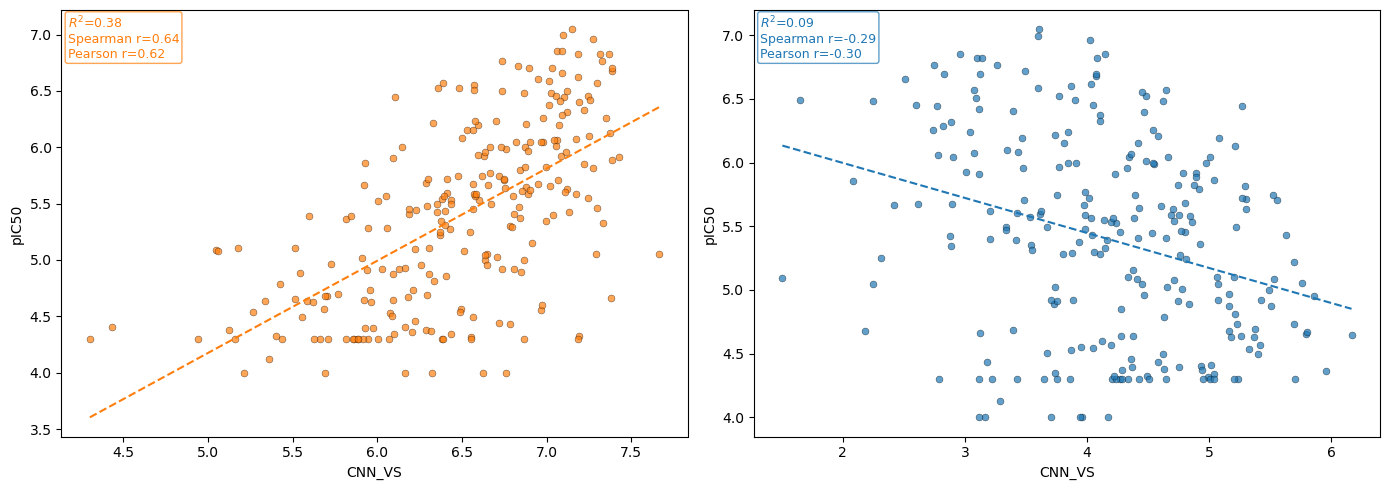

In [18]:
# Plot CNN_VS vs pIC50 in two separate graphs, split by 'run' group, keeping coloring

import matplotlib.pyplot as plt
from scipy.stats import linregress, spearmanr, pearsonr
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

runs = [r for r in combined_df["run"].unique() if r in SCATTER_COLORS]

for i, run_name in enumerate(runs):
    # Subset for this run
    sub = combined_df[combined_df["run"] == run_name]
    # Left: group 1 (first run)
    if i == 0:
        ax = axes[0]
    # Right: group 2 (second run)
    elif i == 1:
        ax = axes[1]
    else:
        continue  # Supports only two groups

    x = sub["CNN_VS"].values
    y = sub["pIC50"].values
    c = SCATTER_COLORS[run_name]
    ax.scatter(x, y, color=c, alpha=0.7, label=RUN_LABELS[run_name], s=25, edgecolor='k', linewidth=0.3)
    mask = ~np.isnan(x) & ~np.isnan(y)
    if mask.sum() > 2:
        slope, intercept, r_value, _, _ = linregress(x[mask], y[mask])
        xs = np.linspace(x[mask].min(), x[mask].max(), 50)
        ax.plot(xs, intercept + slope * xs, color=c, linestyle="--", linewidth=1.5)
        spearman_r, _ = spearmanr(x[mask], y[mask])
        pearson_r, _ = pearsonr(x[mask], y[mask])
        # Annotate statistics
        statstr = (
            f"$R^2$={r_value**2:.2f}\n"
            f"Spearman r={spearman_r:.2f}\n"
            f"Pearson r={pearson_r:.2f}"
        )
        ax.text(
            0.01, 0.99,
            statstr,
            transform=ax.transAxes,
            fontsize=9,
            color=c,
            verticalalignment="top",
            bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.7, edgecolor=c, lw=1),
        )
        print(
            f"{RUN_LABELS[run_name]}  CNN_VS vs pIC50: R²={r_value**2:.3f}  Spearman r={spearman_r:.3f}  Pearson r={pearson_r:.3f}"
        )

# Set axis labels
axes[0].set_xlabel("CNN_VS")
axes[0].set_ylabel("pIC50")

axes[1].set_xlabel("CNN_VS")
axes[1].set_ylabel("pIC50")

# No legend
plt.tight_layout()
plt.savefig("scatter_cnn_vs_pic50.png", dpi=300, bbox_inches='tight')  # Save as high-quality PNG
plt.show()

SAR (frame 7)  class balance:
pIC50
0    187
1     61
Name: count, dtype: int64

SAR (frame 0)  class balance:
pIC50
0    187
1     61
Name: count, dtype: int64



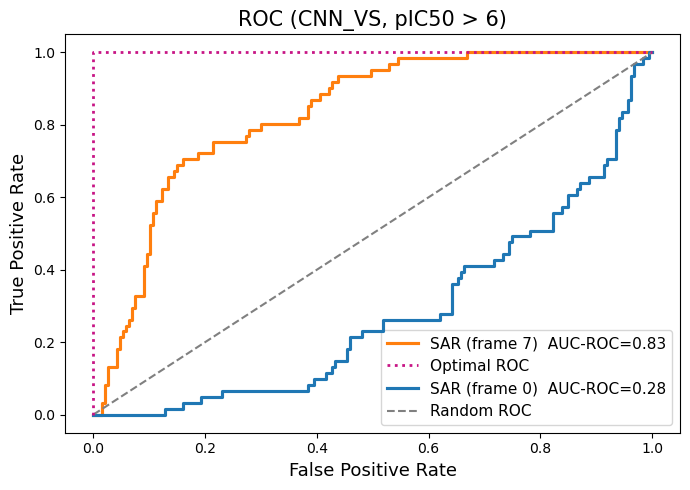

SAR (frame 7)  AUC-PR (CNN_VS): 0.535
SAR (frame 0)  AUC-PR (CNN_VS): 0.168


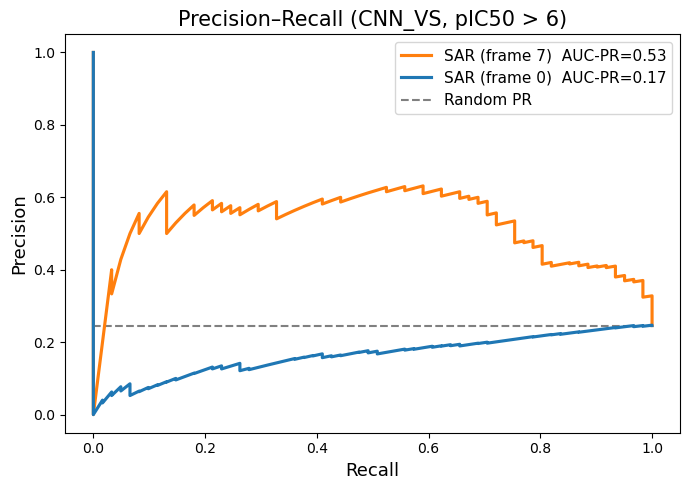

In [25]:
import numpy as np
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve,
)
import matplotlib.patches as mpatches

plt.figure(figsize=(7, 5))
optimal_curve_drawn = False

for run_idx, (run_name, sub) in enumerate(combined_df.groupby("run")):
    y_true = (sub["pIC50"] > 6).astype(int)
    y_score = sub["CNN_VS"]
    mask = y_score.notna() & sub["pIC50"].notna()
    yt = y_true[mask].to_numpy()
    ys = y_score[mask].to_numpy()
    if np.unique(yt).size < 2:
        print(f"{RUN_LABELS[run_name]}: skip ROC (need both classes)")
        continue
    auc_roc = roc_auc_score(yt, ys)
    fpr, tpr, _ = roc_curve(yt, ys)
    color = SCATTER_COLORS[run_name] if "SCATTER_COLORS" in globals() else f"C{run_idx}"
    plt.plot(fpr, tpr, color=color, label=f"{RUN_LABELS[run_name]}  AUC-ROC={auc_roc:.2f}", linewidth=2.25, zorder=10+run_idx)

    # Removed fill under ROC curve

    # Draw "optimal" curve for reference (only once)
    if not optimal_curve_drawn:
        total_pos = np.sum(yt == 1)
        total_neg = np.sum(yt == 0)
        optimal_fpr = np.array([0, 0, 1])
        optimal_tpr = np.array([0, 1, 1])
        # Use different color for optimal
        opt_color = "mediumvioletred"
        plt.plot(optimal_fpr, optimal_tpr, color=opt_color, linestyle=":", linewidth=2, label="Optimal ROC", zorder=30)
        # Removed fill under optimal curve
        optimal_curve_drawn = True

    print(f"{RUN_LABELS[run_name]}  class balance:\n{y_true[mask].value_counts()}\n")

# Add random (diagonal) curve and label
plt.plot([0, 1], [0, 1], linestyle="--", color="grey", linewidth=1.5, label="Random ROC", zorder=25)
# Removed fill under random curve
plt.xlabel("False Positive Rate", fontsize=13)
plt.ylabel("True Positive Rate", fontsize=13)
plt.title("ROC (CNN_VS, pIC50 > 6)", fontsize=15)
plt.legend(fontsize=11, loc='lower right', frameon=True, facecolor='white')
plt.tight_layout()
plt.savefig("roc_curve_cnn_vs_pic50_6.png", dpi=300, bbox_inches='tight')
plt.show()

plt.figure(figsize=(7, 5))

for run_idx, (run_name, sub) in enumerate(combined_df.groupby("run")):
    y_true = (sub["pIC50"] > 6).astype(int)
    y_score = sub["CNN_VS"]
    mask = y_score.notna() & sub["pIC50"].notna()
    yt = y_true[mask].to_numpy()
    ys = y_score[mask].to_numpy()
    if np.unique(yt).size < 2:
        continue
    auc_pr = average_precision_score(yt, ys)
    precision, recall, _ = precision_recall_curve(yt, ys)
    color = SCATTER_COLORS[run_name] if "SCATTER_COLORS" in globals() else f"C{run_idx}"
    plt.plot(recall, precision, color=color, label=f"{RUN_LABELS[run_name]}  AUC-PR={auc_pr:.2f}", linewidth=2.25, zorder=10+run_idx)
    # Removed fill under PR curve
    print(f"{RUN_LABELS[run_name]}  AUC-PR (CNN_VS): {auc_pr:.3f}")

# Add "Random" baseline for PR (y=positive rate)
all_y_true = combined_df["pIC50"] > 6
positive_rate = all_y_true.mean()
plt.hlines(y=positive_rate, xmin=0, xmax=1, colors="grey", linestyle="--", linewidth=1.5, label="Random PR", zorder=0)
plt.xlabel("Recall", fontsize=13)
plt.ylabel("Precision", fontsize=13)
plt.title("Precision–Recall (CNN_VS, pIC50 > 6)", fontsize=15)
plt.legend(fontsize=11, loc='upper right', frameon=True, facecolor='white')
plt.tight_layout()
plt.show()

SAR (frame 7)  class balance:
pIC50
0    132
1    116
Name: count, dtype: int64

SAR (frame 0)  class balance:
pIC50
0    132
1    116
Name: count, dtype: int64



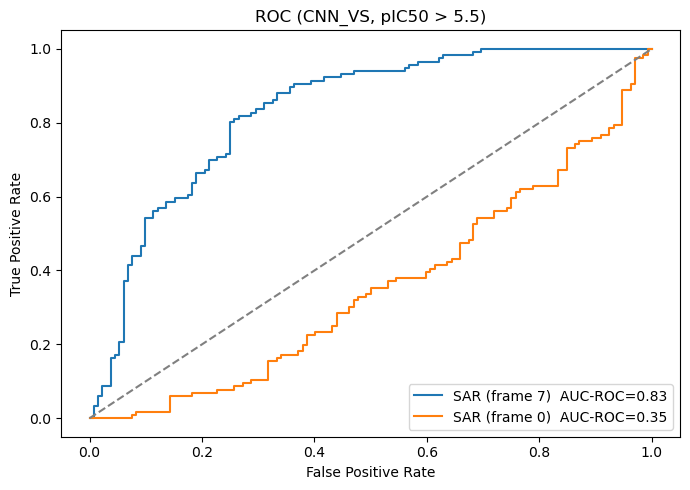

SAR (frame 7)  AUC-PR (CNN_VS): 0.752
SAR (frame 0)  AUC-PR (CNN_VS): 0.373


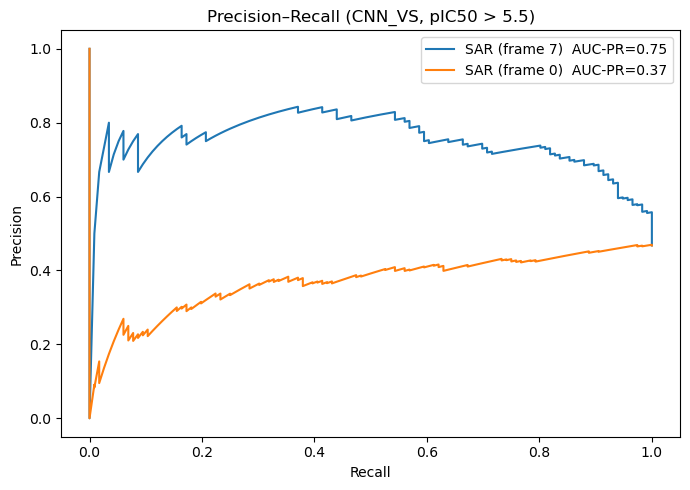

In [20]:
import numpy as np
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve,
)

plt.figure(figsize=(7, 5))
for run_name, sub in combined_df.groupby("run"):
    y_true = (sub["pIC50"] > 5.5).astype(int)
    y_score = sub["CNN_VS"]
    mask = y_score.notna() & sub["pIC50"].notna()
    yt = y_true[mask].to_numpy()
    ys = y_score[mask].to_numpy()
    if np.unique(yt).size < 2:
        print(f"{RUN_LABELS[run_name]}: skip ROC (need both classes)")
        continue
    auc_roc = roc_auc_score(yt, ys)
    fpr, tpr, _ = roc_curve(yt, ys)
    plt.plot(fpr, tpr, label=f"{RUN_LABELS[run_name]}  AUC-ROC={auc_roc:.2f}")
    print(f"{RUN_LABELS[run_name]}  class balance:\n{y_true[mask].value_counts()}\n")

plt.plot([0, 1], [0, 1], linestyle="--", color="grey")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC (CNN_VS, pIC50 > 5.5)")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 5))
for run_name, sub in combined_df.groupby("run"):
    y_true = (sub["pIC50"] > 5.5).astype(int)
    y_score = sub["CNN_VS"]
    mask = y_score.notna() & sub["pIC50"].notna()
    yt = y_true[mask].to_numpy()
    ys = y_score[mask].to_numpy()
    if np.unique(yt).size < 2:
        continue
    auc_pr = average_precision_score(yt, ys)
    precision, recall, _ = precision_recall_curve(yt, ys)
    plt.plot(recall, precision, label=f"{RUN_LABELS[run_name]}  AUC-PR={auc_pr:.2f}")
    print(f"{RUN_LABELS[run_name]}  AUC-PR (CNN_VS): {auc_pr:.3f}")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall (CNN_VS, pIC50 > 5.5)")
plt.legend()
plt.tight_layout()
plt.show()

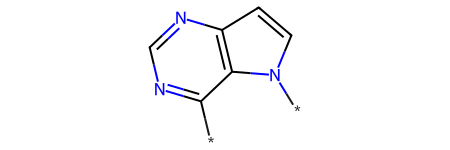

In [4]:
from rdkit import Chem

Chem.MolFromSmiles('*c1ncnc2ccn(*)c12')